In [211]:
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate

In [212]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

In [213]:
import operator
from typing import TypedDict, Annotated

class EssayDiff(TypedDict):
    essay_text:str
    cot_feedback:str
    doa_feedback:str
    language_feedback:str
    final_feedback:str
    final_score:float
    marks:Annotated[list[str], operator.add]


In [214]:
from pydantic.v1 import BaseModel, Field

class Feedback(BaseModel):
    step_feedback: str = Field(description="Feedback for the step")
    score: float = Field(description="Score given to the step")

In [215]:
def clarity_of_thoughts(essay: EssayDiff) -> EssayDiff:
    essay_text = essay["essay_text"]

    parser = PydanticOutputParser(pydantic_object=Feedback)

    prompt = PromptTemplate(
        template="""
You are given an essay. Score its clarity of thought out of 10.

Essay:
{essay_text}

{format_instruction}
""",
        input_variables=["essay_text"],
        partial_variables={
            "format_instruction": parser.get_format_instructions()
        }
    )

    chain = prompt | llm | parser

    output = chain.invoke({
        "essay_text": essay_text
    })

    return {
        "cot_feedback": output.step_feedback,
        "marks": [output.score]
    }

In [216]:
def depth_of_analysis(essay: EssayDiff) -> EssayDiff:
    essay_text = essay["essay_text"]

    parser = PydanticOutputParser(pydantic_object=Feedback)

    prompt = PromptTemplate(
        template="""
You are given an essay. Score its depth of analysis out of 10.
Evaluate how deeply the essay examines ideas, arguments, and evidence.

Essay:
{essay_text}

{format_instruction}
""",
        input_variables=["essay_text"],
        partial_variables={
            "format_instruction": parser.get_format_instructions()
        }
    )

    chain = prompt | llm | parser

    output = chain.invoke({"essay_text": essay_text})

    return {
        "doa_feedback": output.step_feedback,
        "marks": [output.score]
    }

In [217]:
def language(essay: EssayDiff) -> EssayDiff:
    essay_text = essay["essay_text"]

    parser = PydanticOutputParser(pydantic_object=Feedback)

    prompt = PromptTemplate(
        template="""
You are given an essay. Score its language quality out of 10.
Evaluate grammar, vocabulary usage, sentence structure, and clarity.

Essay:
{essay_text}

{format_instruction}
""",
        input_variables=["essay_text"],
        partial_variables={
            "format_instruction": parser.get_format_instructions()
        }
    )

    chain = prompt | llm | parser

    output = chain.invoke({"essay_text": essay_text})

    return {
        "language_feedback": output.step_feedback,
        "marks": [output.score]
    }

In [218]:
def final_eval(essay: EssayDiff) -> EssayDiff:
    scores = essay["marks"]

    if not scores:
        avg_score = 0
    else:
        avg_score = sum(scores) / len(scores)

    final_feedback = f"""
Overall Evaluation:

Clarity of Thought:
{essay["cot_feedback"]}

Depth of Analysis:
{essay["doa_feedback"]}

Language Quality:
{essay["language_feedback"]}

Final Score: {avg_score:.2f}/10

Overall Thoughts:
The essay demonstrates an overall performance based on clarity of ideas,
depth of reasoning, and quality of language. Improvements can focus on
strengthening weaker areas identified above.
"""

    return {
        "final_score": avg_score,
        "final_feedback": final_feedback
    }

In [219]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(EssayDiff)

graph.add_node("clarity_of_thoughts", clarity_of_thoughts)
graph.add_node("depth_of_analysis", depth_of_analysis)
graph.add_node("language", language)
graph.add_node("final_eval", final_eval)

graph.add_edge(START, "clarity_of_thoughts")
graph.add_edge(START, "depth_of_analysis")
graph.add_edge(START, "language")

graph.add_edge("clarity_of_thoughts", "final_eval")
graph.add_edge("depth_of_analysis", "final_eval")
graph.add_edge("language", "final_eval")

graph.add_edge("final_eval", END)

result = graph.compile()

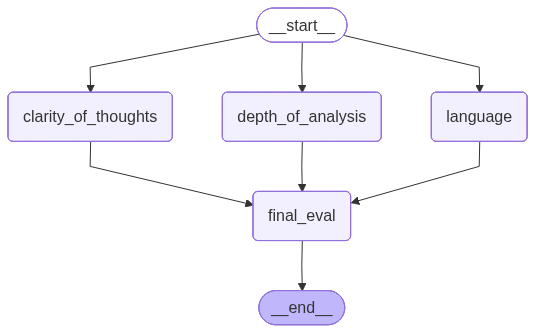

In [220]:
result

In [221]:
from pprint import pprint

essay = """
Artificial intelligence is a thing that is very important nowadays and many people talk about it everywhere. AI is basically computers doing smart things like humans but not exactly humans because they are machines. Many companies are using AI for doing many works which makes things faster and sometimes better but also sometimes not better.

AI is used in many places like hospitals, cars, phones, apps and even games. For example, in hospitals AI can see X-rays and tell doctors things but doctors are already good at that so AI just helps sometimes. Also AI is used in Netflix and YouTube to show videos that people may like but sometimes it shows bad recommendations too which is annoying.

Another thing about AI is that it can take people’s jobs. Many people say robots will replace humans but other people say new jobs will be created so maybe it is good or maybe it is bad. Nobody really knows exactly what will happen in the future because technology changes very fast and things are unpredictable.

Also there are problems like privacy and bias and other technical issues which are discussed by many experts and researchers and governments. These problems are important but solutions are still being figured out and there is a lot of debate about what should be done.

In conclusion AI is both good and bad and it depends on how people use it and how the technology grows in the future. AI will probably continue to grow and people will continue talking about it and trying to manage its effects on society.
"""

ans = result.invoke({
    "essay_text": essay,
    "marks": []
})


pprint(ans)

{'cot_feedback': 'The essay lacks clarity of thought and organization. The '
                 'writer jumps between different ideas without connecting them '
                 'properly.',
 'doa_feedback': 'The essay provides a general overview of artificial '
                 'intelligence but lacks depth in analysis.',
 'essay_text': '\n'
               'Artificial intelligence is a thing that is very important '
               'nowadays and many people talk about it everywhere. AI is '
               'basically computers doing smart things like humans but not '
               'exactly humans because they are machines. Many companies are '
               'using AI for doing many works which makes things faster and '
               'sometimes better but also sometimes not better.\n'
               '\n'
               'AI is used in many places like hospitals, cars, phones, apps '
               'and even games. For example, in hospitals AI can see X-rays '
               'and tell doct